In [3]:
!pip -q install kaggle

In [6]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


In [7]:
!mkdir -p /content/aptos
!kaggle competitions download -c aptos2019-blindness-detection -p /content/aptos

100% 9.51G/9.51G [08:01<00:00, 21.2MB/s]



In [8]:
!ls -lh /content/aptos

total 9.6G
-rw-r--r-- 1 root root 9.6G Dec 18  2019 aptos2019-blindness-detection.zip


In [9]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:
import os

for root, dirs, files in os.walk("/content/aptos"):
    print("\nFOLDER:", root)
    print("FILES:", files[:10])


FOLDER: /content/aptos
FILES: ['aptos2019-blindness-detection.zip']


In [12]:
import os

print(os.listdir("/content/aptos"))

['aptos2019-blindness-detection.zip']


In [14]:
import zipfile
import os

DATA_DIR = "/content/aptos"

for file in os.listdir(DATA_DIR):
    if file.endswith(".zip"):
        zip_path = os.path.join(DATA_DIR, file)

        print("Extracting:", file)

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(DATA_DIR)

print("Extraction completed!")

Extracting: aptos2019-blindness-detection.zip
Extraction completed!


In [15]:
for root, dirs, files in os.walk("/content/aptos"):
    level = root.replace("/content/aptos", "").count(os.sep)

    if level <= 2:
        print("  " * level + os.path.basename(root) + "/")

aptos/
  test_images/
  train_images/


In [16]:
import os

train_image_dir = "/content/aptos/train_images"

images = os.listdir(train_image_dir)

print("Number of training images:", len(images))
print("First 10 images:", images[:10])

Number of training images: 3662
First 10 images: ['e1c02f6c3362.png', '0abf0c485f66.png', '1a03a7970337.png', '5db2e3a4594a.png', 'be8697eb2078.png', '80f6b30ece8c.png', '8433a032b96c.png', '4df6a81b476e.png', '2bb063318cf1.png', '3b232b394e4f.png']


In [17]:
import pandas as pd

df = pd.read_csv("/content/aptos/train.csv")

print(df.head())
print("\nTotal rows:", len(df))
print("\nClasses:")
print(df["diagnosis"].value_counts().sort_index())

        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1
3  002c21358ce6          0
4  005b95c28852          0

Total rows: 3662

Classes:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [18]:
!pip -q install tensorflow opencv-python-headless scikit-learn pandas matplotlib seaborn gradio reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 2.2 MB/s eta 0:00:00


In [19]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
class_counts = df["diagnosis"].value_counts().sort_index()

print(class_counts)

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


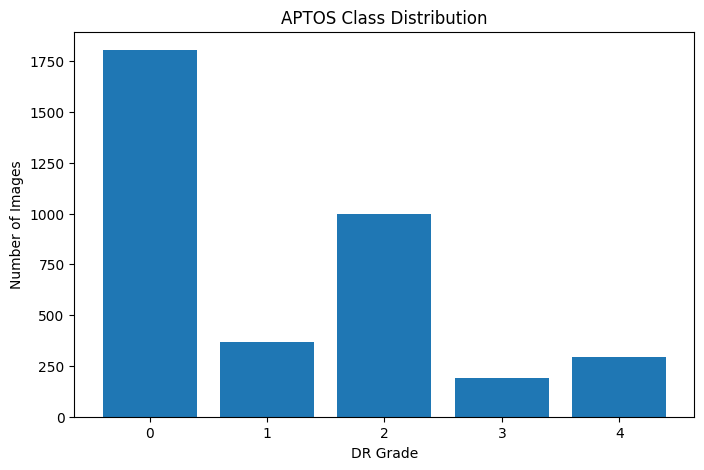

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.xlabel("DR Grade")
plt.ylabel("Number of Images")
plt.title("APTOS Class Distribution")

plt.show()

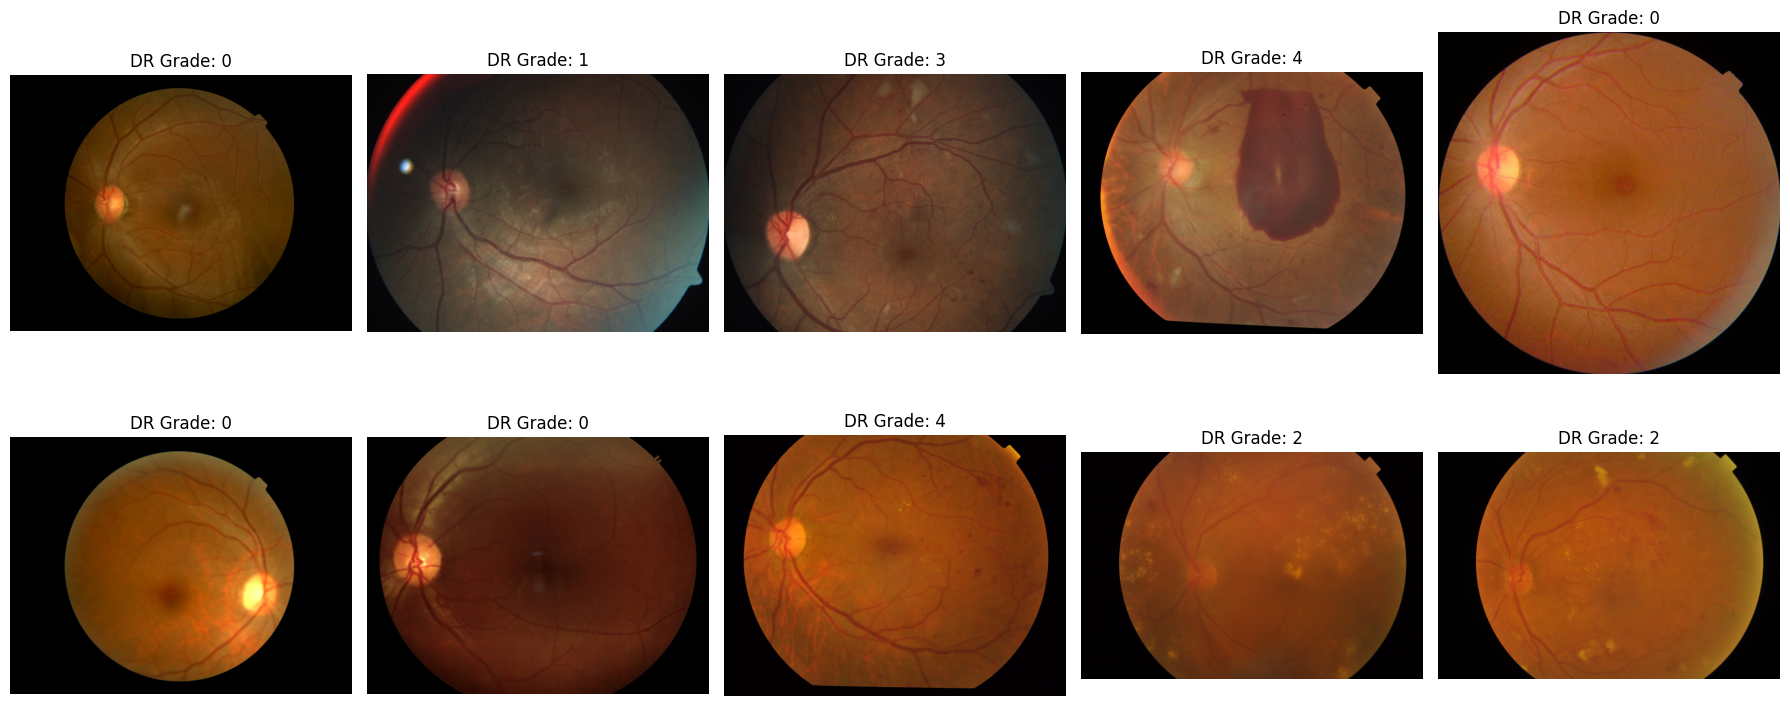

In [24]:
import cv2
import matplotlib.pyplot as plt

samples = df.sample(10, random_state=42)

plt.figure(figsize=(18,8))

for i, (_, row) in enumerate(samples.iterrows()):

    path = os.path.join(
        train_image_dir,
        row["id_code"] + ".png" # Corrected from 'id' to 'id_code'
    )

    image = cv2.imread(path)

    if image is None:
        continue

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,5,i+1)
    plt.imshow(image)
    plt.title(f"DR Grade: {row['diagnosis']}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [25]:
def calculate_sharpness(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    return cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

In [31]:
import numpy as np

def calculate_brightness(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    return np.mean(gray)

In [32]:
import numpy as np

def calculate_contrast(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    return np.std(gray)

In [33]:
def quality_metrics(image):

    sharpness = calculate_sharpness(image)
    brightness = calculate_brightness(image)
    contrast = calculate_contrast(image)

    return {
        "sharpness": sharpness,
        "brightness": brightness,
        "contrast": contrast
    }

In [34]:
sample_id = df.iloc[0]["id_code"]

path = os.path.join(
    train_image_dir, # Corrected from TRAIN_DIR
    sample_id + ".png"
)

image = cv2.imread(path)
image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

metrics = quality_metrics(image)

print(metrics)

{'sharpness': np.float64(6.258778526524421), 'brightness': np.float64(51.388749574925), 'contrast': np.float64(31.303280482505272)}


In [35]:
def quality_decision(metrics):

    sharpness = metrics["sharpness"]
    brightness = metrics["brightness"]
    contrast = metrics["contrast"]

    if sharpness < 50:
        return "UNGRADABLE"

    if brightness < 30 or brightness > 220:
        return "UNGRADABLE"

    if contrast < 25:
        return "BORDERLINE"

    if sharpness < 100:
        return "BORDERLINE"

    return "GOOD"

In [36]:
IMG_SIZE = 224

def preprocess_fundus(image):

    # Convert to grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    # Find non-black region
    _, mask = cv2.threshold(
        gray,
        10,
        255,
        cv2.THRESH_BINARY
    )

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if contours:

        largest = max(
            contours,
            key=cv2.contourArea
        )

        x, y, w, h = cv2.boundingRect(largest)

        image = image[
            y:y+h,
            x:x+w
        ]

    # Resize
    image = cv2.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    # LAB color space
    lab = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    # CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )

    l = clahe.apply(l)

    enhanced = cv2.merge([
        l, a, b
    ])

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_LAB2RGB
    )

    # Mild denoising
    enhanced = cv2.GaussianBlur(
        enhanced,
        (3,3),
        0
    )

    return enhanced

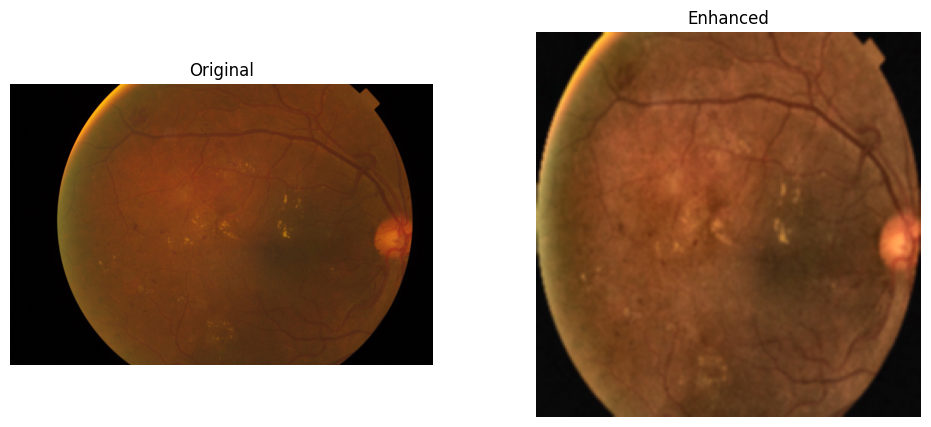

In [37]:
processed = preprocess_fundus(image)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(processed)
plt.title("Enhanced")
plt.axis("off")

plt.show()

In [38]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["diagnosis"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["diagnosis"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 2929
Validation: 366
Test: 367


In [39]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, Model

base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(
    shape=(IMG_SIZE, IMG_SIZE, 3)
)

x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.05)(x)
x = layers.RandomZoom(0.1)(x)
x = layers.RandomContrast(0.1)(x)

x = base_model(
    x,
    training=False
)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.3)(x)

outputs = layers.Dense(
    5,
    activation="softmax"
)(x)

model = Model(
    inputs,
    outputs
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [40]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [49]:
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    directory=train_image_dir, # Corrected from TRAIN_DIR
    x_col="filename", # Changed from 'id_code' to 'filename'
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode="raw",
    shuffle=True
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    directory=train_image_dir, # Corrected from TRAIN_DIR
    x_col="filename", # Changed from 'id_code' to 'filename'
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode="raw",
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    directory=train_image_dir, # Corrected from TRAIN_DIR
    x_col="filename", # Changed from 'id_code' to 'filename'
    y_col="diagnosis",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=16,
    class_mode="raw",
    shuffle=False
)

Found 2929 validated image filenames.
Found 366 validated image filenames.
Found 367 validated image filenames.


In [44]:
train_df["filename"] = train_df["id_code"] + ".png" # Corrected from 'id'
val_df["filename"] = val_df["id_code"] + ".png" # Corrected from 'id'
test_df["filename"] = test_df["id_code"] + ".png" # Corrected from 'id'

In [46]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [50]:
from sklearn.utils import class_weight
import numpy as np

# Calculate class weights
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis']
)

# Convert class weights to a dictionary
class_weights = dict(enumerate(class_weights_array))

callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2
    )
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.1943 - loss: 1.6426 - val_accuracy: 0.4918 - val_loss: 1.4038 - learning_rate: 0.0010
Epoch 2/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.1967 - loss: 1.6515 - val_accuracy: 0.4918 - val_loss: 1.5410 - learning_rate: 0.0010
Epoch 3/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.2004 - loss: 1.6392 - val_accuracy: 0.1011 - val_loss: 1.6344 - learning_rate: 0.0010
Epoch 4/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.1710 - loss: 1.6269 - val_accuracy: 0.0546 - val_loss: 1.6119 - learning_rate: 3.0000e-04
Epoch 5/15
184/184 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.1984 - loss: 1.6260 - val_accuracy: 0.0546 - val_loss: 1.6545 - learning_rate: 3.0000e-04


In [51]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

fine_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 413s 2s/step - accuracy: 0.2325 - loss: 1.6507 - val_accuracy: 0.4918 - val_loss: 1.5254 - learning_rate: 1.0000e-05
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.2161 - loss: 1.6358 - val_accuracy: 0.1011 - val_loss: 1.6065 - learning_rate: 1.0000e-05
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 393s 2s/step - accuracy: 0.1956 - loss: 1.6288 - val_accuracy: 0.0792 - val_loss: 1.6028 - learning_rate: 3.0000e-06
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 397s 2s/step - accuracy: 0.1960 - loss: 1.6335 - val_accuracy: 0.0792 - val_loss: 1.6266 - learning_rate: 3.0000e-06


In [52]:
test_loss, test_accuracy = model.evaluate(test_gen)

print("Test Accuracy:", test_accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.4932 - loss: 1.5245
Test Accuracy: 0.4931880235671997


In [53]:
from sklearn.metrics import confusion_matrix, classification_report

test_gen.reset()

y_prob = model.predict(test_gen)

y_pred = np.argmax(
    y_prob,
    axis=1
)

y_true = test_df["diagnosis"].values

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "No DR",
            "Mild",
            "Moderate",
            "Severe",
            "Proliferative"
        ]
    )
)

23/23 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step
               precision    recall  f1-score   support

        No DR       0.49      1.00      0.66       181
         Mild       0.00      0.00      0.00        37
     Moderate       0.00      0.00      0.00       100
       Severe       0.00      0.00      0.00        19
Proliferative       0.00      0.00      0.00        30

     accuracy                           0.49       367
    macro avg       0.10      0.20      0.13       367
 weighted avg       0.24      0.49      0.33       367



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


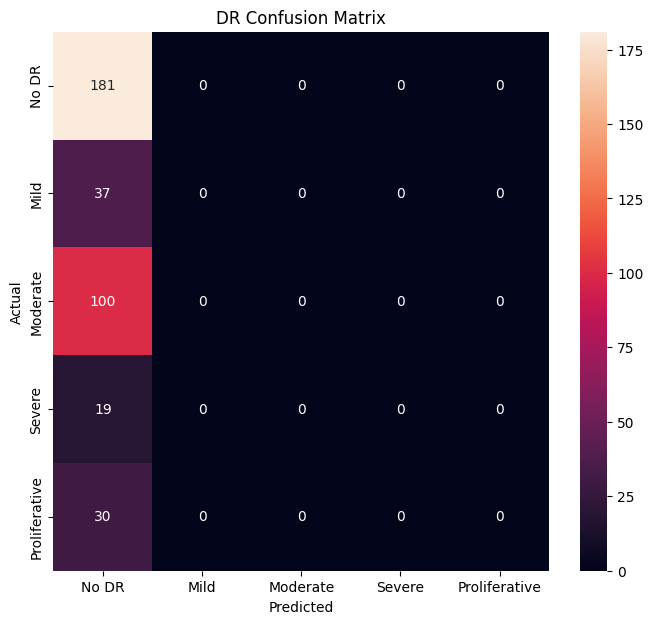

In [54]:
import seaborn as sns

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative"
    ],
    yticklabels=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DR Confusion Matrix")

plt.show()

In [55]:
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

y_true_binary = (
    y_true >= 2
).astype(int)

y_pred_binary = (
    y_pred >= 2
).astype(int)

binary_cm = confusion_matrix(
    y_true_binary,
    y_pred_binary
)

TN, FP, FN, TP = binary_cm.ravel()

sensitivity = TP / (TP + FN)

specificity = TN / (TN + FP)

precision = TP / (TP + FP)

f1 = 2 * precision * sensitivity / (
    precision + sensitivity
)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("Precision:", precision)
print("F1:", f1)

Sensitivity: 0.0
Specificity: 1.0
Precision: nan
F1: nan


/tmp/ipykernel_1128/3450568782.py:27: RuntimeWarning: invalid value encountered in scalar divide
  precision = TP / (TP + FP)


In [56]:
for layer in model.layers:
    print(layer.name, layer.__class__.__name__)

input_layer_1 InputLayer
random_flip RandomFlip
random_rotation RandomRotation
random_zoom RandomZoom
random_contrast RandomContrast
efficientnetb0 Functional
global_average_pooling2d GlobalAveragePooling2D
dropout Dropout
dense Dense


In [57]:
for layer in base_model.layers[-20:]:
    print(layer.name, layer.__class__.__name__)

block6d_project_conv Conv2D
block6d_project_bn BatchNormalization
block6d_drop Dropout
block6d_add Add
block7a_expand_conv Conv2D
block7a_expand_bn BatchNormalization
block7a_expand_activation Activation
block7a_dwconv DepthwiseConv2D
block7a_bn BatchNormalization
block7a_activation Activation
block7a_se_squeeze GlobalAveragePooling2D
block7a_se_reshape Reshape
block7a_se_reduce Conv2D
block7a_se_expand Conv2D
block7a_se_excite Multiply
block7a_project_conv Conv2D
block7a_project_bn BatchNormalization
top_conv Conv2D
top_bn BatchNormalization
top_activation Activation


In [58]:
import tensorflow as tf
import numpy as np
import cv2

def make_gradcam(
    model,
    image,
    last_conv_layer_name
):

    grad_model = tf.keras.models.Model(
        [
            model.inputs
        ],
        [
            model.get_layer(
                last_conv_layer_name
            ).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(
            image
        )

        predicted_class = tf.argmax(
            predictions[0]
        )

        class_output = predictions[
            0,
            predicted_class
        ]

    grads = tape.gradient(
        class_output,
        conv_outputs
    )

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    heatmap = tf.maximum(
        heatmap,
        0
    )

    heatmap /= (
        tf.reduce_max(heatmap) + 1e-8
    )

    return heatmap.numpy()


Image path:
/content/aptos/train_images/3580a545016d.png

Processed image shape: (224, 224, 3)
Model input shape: (1, 224, 224, 3)
Base model      : efficientnetb0
Grad-CAM layer  : top_conv

          DR PREDICTION
Predicted DR Grade: 0

Class probabilities:
Grade 0: 0.2486 (24.86%)
Grade 1: 0.2237 (22.37%)
Grade 2: 0.1907 (19.07%)
Grade 3: 0.1538 (15.38%)
Grade 4: 0.1832 (18.32%)


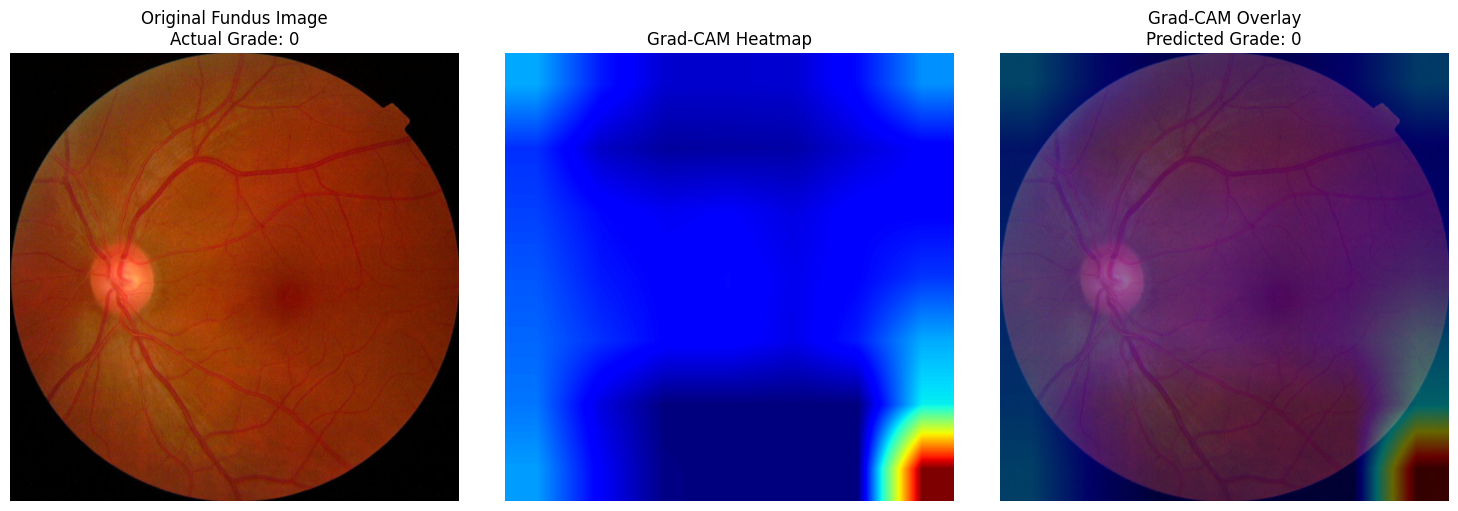

In [67]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os


# ============================================================
# 1. GRAD-CAM FUNCTION
# ============================================================

def make_gradcam(model, image,
                 base_model_name="efficientnetb0",
                 conv_layer_name="top_conv"):

    # --------------------------------------------------------
    # Get the nested EfficientNetB0 model
    # --------------------------------------------------------
    base_model = model.get_layer(base_model_name)

    # --------------------------------------------------------
    # Get the convolutional layer inside EfficientNetB0
    # --------------------------------------------------------
    conv_layer = base_model.get_layer(conv_layer_name)

    print("Base model      :", base_model.name)
    print("Grad-CAM layer  :", conv_layer.name)

    # --------------------------------------------------------
    # Create a model:
    #
    # EfficientNet input
    #       ↓
    # convolution output
    #       +
    # EfficientNet output
    #
    # We DON'T connect this directly to model.output.
    # This avoids the Keras nested-model graph error.
    # --------------------------------------------------------

    grad_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[
            conv_layer.output,
            base_model.output
        ]
    )

    # --------------------------------------------------------
    # Gradient calculation
    # --------------------------------------------------------

    with tf.GradientTape() as tape:

        # Run EfficientNetB0
        conv_outputs, features = grad_model(
            image,
            training=False
        )

        # -----------------------------------------------
        # Pass EfficientNet features through the layers
        # AFTER EfficientNetB0
        # -----------------------------------------------

        x = features

        found_base = False

        for layer in model.layers:

            if layer.name == base_model_name:
                found_base = True
                continue

            if found_base:
                x = layer(x, training=False)

        predictions = x

        # ------------------------------------------------
        # Find predicted class
        # ------------------------------------------------

        predicted_class = tf.argmax(
            predictions[0]
        )

        # Score of predicted class
        class_score = predictions[
            0,
            predicted_class
        ]

    # --------------------------------------------------------
    # Calculate gradients
    # --------------------------------------------------------

    grads = tape.gradient(
        class_score,
        conv_outputs
    )

    # --------------------------------------------------------
    # Average gradients across width and height
    # --------------------------------------------------------

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0, 1, 2)
    )

    # Remove batch dimension
    conv_outputs = conv_outputs[0]

    # --------------------------------------------------------
    # Weight feature maps by their gradients
    # --------------------------------------------------------

    heatmap = tf.reduce_sum(
        conv_outputs * pooled_grads,
        axis=-1
    )

    # --------------------------------------------------------
    # Keep only positive influence
    # --------------------------------------------------------

    heatmap = tf.maximum(
        heatmap,
        0
    )

    # --------------------------------------------------------
    # Normalize heatmap between 0 and 1
    # --------------------------------------------------------

    heatmap = heatmap / (
        tf.reduce_max(heatmap) + 1e-8
    )

    return (
        heatmap.numpy(),
        int(predicted_class.numpy()),
        predictions.numpy()
    )


# ============================================================
# 2. GET A SAMPLE IMAGE
# ============================================================

sample_image_id = test_df.iloc[0]["id_code"]

sample_image_path = os.path.join(
    train_image_dir,
    sample_image_id + ".png"
)

print("\nImage path:")
print(sample_image_path)


# ============================================================
# 3. LOAD ORIGINAL IMAGE
# ============================================================

original_image = cv2.imread(
    sample_image_path
)

if original_image is None:

    raise FileNotFoundError(
        "Image could not be loaded:\n"
        + sample_image_path
    )

# OpenCV BGR → RGB
original_image = cv2.cvtColor(
    original_image,
    cv2.COLOR_BGR2RGB
)


# ============================================================
# 4. PREPROCESS IMAGE
# ============================================================

processed_image = preprocess_fundus(
    original_image
)

print(
    "\nProcessed image shape:",
    processed_image.shape
)


# ============================================================
# 5. PREPARE MODEL INPUT
# ============================================================

input_tensor = (
    processed_image.astype(np.float32)
    / 255.0
)

# Add batch dimension
input_tensor = np.expand_dims(
    input_tensor,
    axis=0
)

# Convert NumPy → TensorFlow tensor
input_tensor = tf.convert_to_tensor(
    input_tensor,
    dtype=tf.float32
)

print(
    "Model input shape:",
    input_tensor.shape
)


# ============================================================
# 6. GENERATE GRAD-CAM
# ============================================================

heatmap, predicted_class, probabilities = make_gradcam(
    model=model,
    image=input_tensor,
    base_model_name="efficientnetb0",
    conv_layer_name="top_conv"
)


# ============================================================
# 7. PRINT PREDICTION
# ============================================================

print("\n" + "=" * 45)
print("          DR PREDICTION")
print("=" * 45)

print(
    "Predicted DR Grade:",
    predicted_class
)

print("\nClass probabilities:")

for i, probability in enumerate(probabilities[0]):

    print(
        f"Grade {i}: {probability:.4f} "
        f"({probability * 100:.2f}%)"
    )

print("=" * 45)


# ============================================================
# 8. RESIZE GRAD-CAM HEATMAP
# ============================================================

heatmap_resized = cv2.resize(
    heatmap,
    (
        original_image.shape[1],
        original_image.shape[0]
    )
)


# ============================================================
# 9. CONVERT HEATMAP TO COLOR
# ============================================================

heatmap_uint8 = np.uint8(
    255 * heatmap_resized
)

heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# BGR → RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)


# ============================================================
# 10. CREATE OVERLAY
# ============================================================

overlay = cv2.addWeighted(
    original_image,
    0.6,
    heatmap_color,
    0.4,
    0
)


# ============================================================
# 11. DISPLAY RESULTS
# ============================================================

plt.figure(figsize=(15, 5))


# Original image
plt.subplot(1, 3, 1)

plt.imshow(original_image)

plt.title(
    f"Original Fundus Image\n"
    f"Actual Grade: {test_df.iloc[0]['diagnosis']}"
)

plt.axis("off")


# Grad-CAM
plt.subplot(1, 3, 2)

plt.imshow(
    heatmap_resized,
    cmap="jet"
)

plt.title(
    "Grad-CAM Heatmap"
)

plt.axis("off")


# Overlay
plt.subplot(1, 3, 3)

plt.imshow(
    overlay
)

plt.title(
    f"Grad-CAM Overlay\n"
    f"Predicted Grade: {predicted_class}"
)

plt.axis("off")


plt.tight_layout()

plt.show()

In [68]:
def detect_bright_regions(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_RGB2GRAY
    )

    # Threshold very bright regions
    threshold = cv2.threshold(
        gray,
        200,
        255,
        cv2.THRESH_BINARY
    )[1]

    # Remove tiny noise
    kernel = np.ones(
        (3,3),
        np.uint8
    )

    threshold = cv2.morphologyEx(
        threshold,
        cv2.MORPH_OPEN,
        kernel
    )

    return threshold

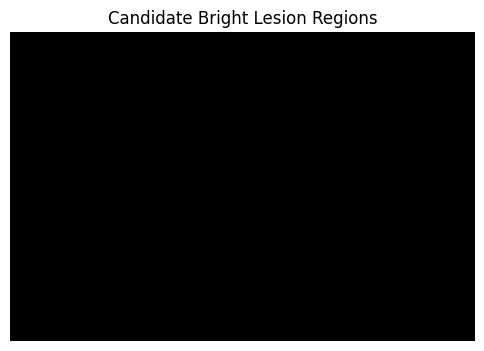

In [69]:
mask = detect_bright_regions(image)

plt.figure(figsize=(6,6))
plt.imshow(mask, cmap="gray")
plt.title("Candidate Bright Lesion Regions")
plt.axis("off")
plt.show()

In [70]:
def generate_report(
    image_quality,
    dr_grade,
    confidence,
    referable,
    evidence
):

    grade_names = {
        0: "No DR",
        1: "Mild DR",
        2: "Moderate DR",
        3: "Severe DR",
        4: "Proliferative DR"
    }

    report = f"""
========================================
       RETINA-XAI SCREENING REPORT
========================================

Image Quality:
{image_quality}

DR Grade:
Level {dr_grade} - {grade_names[dr_grade]}

Confidence:
{confidence:.2%}

Referable DR:
{"YES" if referable else "NO"}

Clinical Evidence:
"""

    for item in evidence:
        report += f"✓ {item}\n"

    report += """

Recommendation:
"""

    if referable:
        report += "REFER TO OPHTHALMOLOGIST\n"
    else:
        report += "ROUTINE SCREENING / FOLLOW-UP\n"

    report += """
----------------------------------------
AI-assisted screening.
Clinical validation required.
========================================
"""

    return report

In [71]:
report = generate_report(
    image_quality="GOOD",
    dr_grade=3,
    confidence=0.94,
    referable=True,
    evidence=[
        "Hemorrhage candidate regions",
        "Exudate candidate regions",
        "Grad-CAM abnormality"
    ]
)

print(report)


       RETINA-XAI SCREENING REPORT

Image Quality:
GOOD

DR Grade:
Level 3 - Severe DR

Confidence:
94.00%

Referable DR:
YES

Clinical Evidence:
✓ Hemorrhage candidate regions
✓ Exudate candidate regions
✓ Grad-CAM abnormality


Recommendation:
REFER TO OPHTHALMOLOGIST

----------------------------------------
AI-assisted screening.
Clinical validation required.



In [72]:
def predict_dr(image):

    processed = preprocess_fundus(
        image
    )

    resized = cv2.resize(
        processed,
        (IMG_SIZE, IMG_SIZE)
    )

    input_img = (
        resized.astype(np.float32)
        / 255.0
    )

    input_img = np.expand_dims(
        input_img,
        axis=0
    )

    probabilities = model.predict(
        input_img,
        verbose=0
    )[0]

    predicted_class = int(
        np.argmax(probabilities)
    )

    confidence = float(
        probabilities[predicted_class]
    )

    quality = quality_decision(
        quality_metrics(image)
    )

    referable = predicted_class >= 2

    result = generate_report(
        quality,
        predicted_class,
        confidence,
        referable,
        ["AI prediction + Grad-CAM evidence"]
    )

    return result

In [74]:
import gradio as gr

demo = gr.Interface(
    fn=predict_dr,
    inputs=gr.Image(
        type="numpy",
        label="Upload Fundus Image"
    ),
    outputs=gr.Textbox(
        label="Screening Report"
    ),
    title="RETINA-XAI",
    description="Explainable AI-based Diabetic Retinopathy Screening"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9292b0c7bf8085b33e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
